# Face Recognition with OpenCV

Building on our previous blog wherein we covered the topic of face detection, we will now be using OpenCV to illustrate how not only can you use computers to detect faces, so too can you use them to recognize specific faces.

In [1]:
# @title Contact Software Sushi {"display-mode":"form"}
import base64
import requests
import urllib.request
from IPython.display import display, HTML

image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/company/logo.png"
with urllib.request.urlopen(image_url) as response:
    image_data = response.read()
    encoded_image = base64.b64encode(image_data).decode()

def load_html_from_github(raw_url):
    response = requests.get(raw_url)
    html_content = response.text
    updated_html = html_content.replace('../images/logo.png', f"data:image/png;base64, {encoded_image}")
    display(HTML(updated_html))

load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner-with-logo.html')

### Imports & Sample Images

In [ ]:
!pip uninstall opencv-python opencv-contrib-python -y
%pip install opencv-contrib-python==4.10.0.84 --force-reinstall

Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86


   ---------------------------------------- 0.0/45.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/45.5 MB 6.7 MB/s eta 0:00:07
   -- ------------------------------------- 3.1/45.5 MB 10.2 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/45.5 MB 11.5 MB/s eta 0:00:04
   -------- ------------------------------- 9.7/45.5 MB 13.1 MB/s eta 0:00:03
   ----------- ---------------------------- 13.6/45.5 MB 14.2 MB/s eta 0:00:03
   -------------- ------------------------- 16.5/45.5 MB 14.3 MB/s eta 0:00:03
   ----------------- ---------------------- 19.4/45.5 MB 14.4 MB/s eta 0:00:02
   ------------------- -------------------- 22.3/45.5 MB 14.1 MB/s eta 0:00:02
   ---------------------- ----------------- 25.4/45.5 MB 14.4 MB/s eta 0:00:02
   ------------------------- -------------- 28.8/45.5 MB 14.6 MB/s eta 0:00:02
   ---------------------------- ----------- 32.2/45.5 MB 14.7 MB/s eta 0:00:01
   ------------------------------ --------- 34.9/45.5 MB 14.7 MB/s

In [3]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import base64
import os

from IPython.display import HTML, display
from io import BytesIO
from PIL import Image

### Utils

In [4]:
# Function for the creation of flexible MatPlotLib figures
def create_mpl_figure(w,h,images,titles="Image",axis="off",color_maps=None):
    plt.figure(figsize=[w,h])

    for i, image in enumerate(images):
        plt.subplot(1,len(images),i+1);

        if color_maps is None:
            plt.imshow(image);
        elif len(color_maps) > 1:
            plt.imshow(image, cmap=f"{color_maps[i]}");
        else:
            plt.imshow(image, cmap=f"{color_maps[0]}")

        plt.title(titles[i]);
        plt.axis(axis);

## Face Recognition Process

Unlike face detection, which was demonstrated in the previous blog, facial recognition is quite a bit more complex than using a pre-built method in OpenCV to process images. This blog will illustrate the use of the Local Binary Pattern Histogram (LBPH) method. This process functions by first taking as an input a face then dividing that face into a grid of small regions. From there, binary patterns are extracted by comparing each pixel within the small region to its neighboring pixels. Histograms are then created for each region, and finally, the histograms for every single region is concatenated to a vector representative of the particular face.

## Use Cases

Face Recognition is used all the time, whether it be for biometric authentication, use in Law Enforcement scenarios through CCTV, or a variety of other circumstances. The uses for it are growing consistently, and show no sign of slowing down.

## Utilizing Local Binary Pattern Histograms

### Fetching our sample faces

Unlike the previous blog, where we detected faces within a given image, we will be using an existing dataset of 400 images of 40 different faces at 10 images per face. If one were to instead want to do this with their own dataset, all of the same steps can be followed, just substituting the sample data with their own. For this purpose then, it is unnecessary to use Haar Cascades to first detect the faces, since the images are all cropped faces.

In [9]:
import urllib.request
import zipfile
import os

# Download the face dataset
url = "https://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip"
zip_filename = "att_faces.zip"

print("Downloading face dataset...")
urllib.request.urlretrieve(url, zip_filename)
print("Download complete!")

# Create faces directory
os.makedirs("faces", exist_ok=True)

# Extract the zip file
print("Extracting files...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("faces")
print("Extraction complete!")

# Clean up the zip file
os.remove(zip_filename)
print("Dataset ready for use!")

Download complete!
Extracting files...
Download complete!
Extracting files...
Extraction complete!
Dataset ready for use!
Extraction complete!
Dataset ready for use!


### Preparing the Data

After retrieving our face images, we now need to transform them into a usable format for the LBPH process. If you look closely, you will notice that of our sample size of 10 photos per person, 9 are fed to the recognizer, while 1 is held back, which will allow us to properly test later on whether or not the recognizer is able to accurately determine whether or not it recognizes a face.

In [10]:
base_path = './faces'
test_faces = []
test_labels = []
faces = []
labels = []

for label in range(1, 41):  # 40 people
    for i in range(1, 11):  # 10 images per person
        img_path = f'{base_path}/s{label}/{i}.pgm'
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if i == 10:
            # Reserve the 10th image of each person for testing
            test_faces.append(img)
            test_labels.append(label)
        else:
            faces.append(img)
            labels.append(label)

### Training Using the Faces

Now that we have our faces downloaded, we need to train the recognizer to actually be able to see and recognize each of the 10 different faces. In order to do this, we needed to install a wrapper package called opencv-contrib-python. This library contains the cv2.face property, which we need to access for the training of the recognizer.

In [11]:
import cv2.face

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(faces, np.array(labels))

### Testing the Recognizer

Now that we have fed the recognizer 9 pictures for each face, we will take the test faces and display them side by side to see how the recognizer does in ascertaining whether it recognizes a given face. It is very important to note here that confidence scoring in the LBPH method is an inverse to what one might normally assume.

Higher numbers = Lower confidence (100<=)
Lower numbers = Higher confidence (<=50)

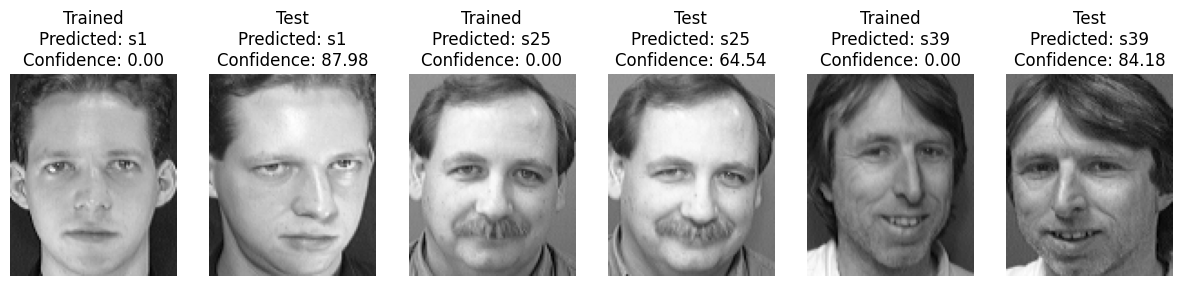

In [12]:
trained_path_1 = 'faces/s1/1.pgm'
test_path_2 = 'faces/s1/10.pgm'

trained_path_3 = 'faces/s25/6.pgm'
test_path_4 = 'faces/s25/10.pgm'

trained_path_5 = 'faces/s39/2.pgm'
test_path_6 = 'faces/s39/10.pgm'

trained_img_1 = cv2.imread(trained_path_1, cv2.IMREAD_GRAYSCALE)
test_img_2 = cv2.imread(test_path_2, cv2.IMREAD_GRAYSCALE)

trained_img_3 = cv2.imread(trained_path_3, cv2.IMREAD_GRAYSCALE)
test_img_4 = cv2.imread(test_path_4, cv2.IMREAD_GRAYSCALE)

trained_img_5 = cv2.imread(trained_path_5, cv2.IMREAD_GRAYSCALE)
test_img_6 = cv2.imread(test_path_6, cv2.IMREAD_GRAYSCALE)

predicted_label_1, confidence_1 = recognizer.predict(trained_img_1)

predicted_label_2, confidence_2 = recognizer.predict(test_img_2)

predicted_label_3, confidence_3 = recognizer.predict(trained_img_3)

predicted_label_4, confidence_4 = recognizer.predict(test_img_4)

predicted_label_5, confidence_5 = recognizer.predict(trained_img_5)

predicted_label_6, confidence_6 = recognizer.predict(test_img_6)

imgs = [trained_img_1, test_img_2, trained_img_3, test_img_4, trained_img_5, test_img_6]

img_titles = [f'Trained\nPredicted: s{predicted_label_1}\nConfidence: {confidence_1:.2f}', f'Test\nPredicted: s{predicted_label_2}\nConfidence: {confidence_2:.2f}', f'Trained\nPredicted: s{predicted_label_3}\nConfidence: {confidence_3:.2f}', f'Test\nPredicted: s{predicted_label_4}\nConfidence: {confidence_4:.2f}', f'Trained\nPredicted: s{predicted_label_5}\nConfidence: {confidence_5:.2f}', f'Test\nPredicted: s{predicted_label_6}\nConfidence: {confidence_6:.2f}']

create_mpl_figure(15, 10, imgs, img_titles, color_maps=["gray"])

## Conclusion

That is how you implement facial recognition using OpenCV! Though a bit more complex than face detection, once the rudiments of the process are understood, its flexibility and usefulness become readily apparent. In the next blog, we will be doing yet another complex facial detection task, namely, the application of angle-correct custom facial filters, such as the overlaying of a dog's face onto a face captured within the image.

## Credits

The face images used in this project are from the ORL Database of Faces, originally maintained by AT&T Laboratories Cambridge.

The dataset contains 400 grayscale images of 40 individuals, each with 10 different poses or expressions.

Dataset source: https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html

The dataset is provided for research and educational use only.

In [ ]:
# @title Contact Software Sushi
load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner.html')